# Applied Validation: Power-Flow Stress and Expansion Costs

The joint SWF + ÜZW run (`joint_setup.RUN_ID`) in the status quo and after electrification without HEMS
(INFLEX) and with HEMS, for the synthetic and the real grids. The paper figure and tables pool the providers as
*Real* and *Synthetic*; the per-provider views are diagnostics only.

**Grid set.**
- Power flow: the grids with non-converged hours in at least 1 % of the hours of any case are left out of every
  case of their group (`joint_setup.MIN_FAILED_SHARE`).
- Expansion costs: in addition, every real grid whose cost is incomplete in one of the cases. The materialization
  gives no cost to a real grid with non-converged hours, because its P100 loading is unknown. All cases then cover
  the same grids. Both lists are shown below.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from gridexpand.analysis.expansion.notebook_workflow import (
    PROVIDER_LABELS,
    expansion_cost_comparison,
    expansion_cost_reduction_summary,
    expansion_grid_costs,
    export_scenario_analysis_manifest,
    group_network,
    load_cable_loading_decomposition,
    load_powerflow_cutoff_comparison,
    load_transformer_import_distributions_for_specs,
    load_voltage_summaries_for_powerflow_comparison,
)
from gridexpand.analysis.plotting.expansion_cost_plots import plot_expansion_cost_comparison_bar
from gridexpand.analysis.plotting.powerflow_asset_plots import (
    plot_cable_capacity_current_loading_comparison,
    plot_powerflow_asset_cutoff_overview_static,
)
from gridexpand.analysis.plotting.powerflow_transformer import plot_transformer_import_distributions_matplotlib
from gridexpand.analysis.plotting.powerflow_voltage import plot_voltage_deviation_histogram_comparison
from joint_setup import CASE_COLORS, CASE_DISPLAY, CURVE_Y_LIMITS, OUTPUT_DIR, STAGE_LABELS, prepare_joint_analysis

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

context = prepare_joint_analysis()
CASES = list(STAGE_LABELS.values())
PRE, INFLEX, HEMS = STAGE_LABELS["pre"], STAGE_LABELS["post_inflex"], STAGE_LABELS["post_flex"]
FIGURE_DIR = OUTPUT_DIR / "expansion"
export_scenario_analysis_manifest(context, output_dir=FIGURE_DIR, excluded_grids=context["excluded_grids"])

{'manifest': PosixPath('/home/breveron/git/github/diss/SurroGrid/GridExpand/work/analysis/output/plots/joint_2045_v1_full_year/expansion/scenario_analysis_manifest.json'),
 'powerflow_readiness': PosixPath('/home/breveron/git/github/diss/SurroGrid/GridExpand/work/analysis/output/plots/joint_2045_v1_full_year/expansion/powerflow_readiness.csv'),
 'publication_gate': PosixPath('/home/breveron/git/github/diss/SurroGrid/GridExpand/work/analysis/output/plots/joint_2045_v1_full_year/expansion/publication_gate.csv')}

## Readiness

The gate checks the raw run: `compact power-flow runs complete` fails as long as any grid has non-converged hours,
also the grids excluded below.

In [2]:
display(context["powerflow_status"])
display(context["publication_gate"])
display(context["analysis_status"])
if not context["publication_ready"]:
    print("DIAGNOSTIC: at least one readiness check failed (see the gate above).")

,data_source,stage,run_name,expected_grids,launched_grids,summary_grids,pending_or_missing_summaries,grids_with_failed_timesteps,failed_timesteps,timestep_signatures,scenario_labels,profile_contracts,complete
0,Real SWF,status-quo,joint_2045_v1_full_year_swf_real_swf_pre,49,49,49,0,1,673,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
1,Real SWF,INFLEX,joint_2045_v1_full_year_swf_real_swf_post-infl...,49,48,48,0,10,9746,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
2,Real SWF,HEMS,joint_2045_v1_full_year_swf_real_swf_post-hems...,49,48,48,0,10,8728,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
3,Synthetic SWF,status-quo,joint_2045_v1_full_year_swf_synthetic_pre,52,52,52,0,0,0,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,True
4,Synthetic SWF,INFLEX,joint_2045_v1_full_year_swf_synthetic_post-inf...,52,52,52,0,3,6,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
5,Synthetic SWF,HEMS,joint_2045_v1_full_year_swf_synthetic_post-hem...,52,52,52,0,2,9,8760,joint_2045_v1_full_year_swf_post-hems-heuristic,physical_building_component_paired_v2,False
6,Real ÜZW,status-quo,joint_2045_v1_full_year_uzw_real_uzw_pre,213,213,213,0,0,0,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,True
7,Real ÜZW,INFLEX,joint_2045_v1_full_year_uzw_real_uzw_post-infl...,213,213,213,0,1,35,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,False
8,Real ÜZW,HEMS,joint_2045_v1_full_year_uzw_real_uzw_post-hems...,213,213,213,0,1,34,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,False
9,Synthetic ÜZW,status-quo,joint_2045_v1_full_year_uzw_synthetic_pre,230,230,230,0,0,0,8760,joint_2045_v1_full_year_uzw_post-hems-heuristic,physical_building_component_paired_v2,True


,check,passed,detail
0,All 12 compact power-flow runs complete,False,1630 grid-stage summaries; 19231 failed timesteps
1,Shared temporal horizon,True,8760
2,Scenario labels of this run,True,joint_2045_v1_full_year_swf_post-hems-heuristi...
3,Single paired profile contract,True,physical_building_component_paired_v2
4,12 matching synthetic/real expansion materiali...,False,0/12 available
5,All materialized grid costs complete,False,0 incomplete and 0 explicitly excluded grid-st...


,stage_label,analysis_key,available,data_source,run_name,stage,grids_with_expansion_summary,grids_total,grids_complete,grids_incomplete,grids_excluded,total_cost_eur
0,status-quo,joint_2045_v1_full_year_swf_real_pre,False,None,None,None,0,0,0,0,0,NaN
1,INFLEX,joint_2045_v1_full_year_swf_real_post_inflex,False,None,None,None,0,0,0,0,0,NaN
2,HEMS,joint_2045_v1_full_year_swf_real_post,False,None,None,None,0,0,0,0,0,NaN
3,status-quo,joint_2045_v1_full_year_swf_synthetic_pre,False,None,None,None,0,0,0,0,0,NaN
4,INFLEX,joint_2045_v1_full_year_swf_synthetic_post_inflex,False,None,None,None,0,0,0,0,0,NaN
5,HEMS,joint_2045_v1_full_year_swf_synthetic_post,False,None,None,None,0,0,0,0,0,NaN
6,status-quo,joint_2045_v1_full_year_uzw_real_pre,False,None,None,None,0,0,0,0,0,NaN
7,INFLEX,joint_2045_v1_full_year_uzw_real_post_inflex,False,None,None,None,0,0,0,0,0,NaN
8,HEMS,joint_2045_v1_full_year_uzw_real_post,False,None,None,None,0,0,0,0,0,NaN
9,status-quo,joint_2045_v1_full_year_uzw_synthetic_pre,False,None,None,None,0,0,0,0,0,NaN


DIAGNOSTIC: at least one readiness check failed (see the gate above).


## Non-converged grids

In [3]:
display(context["nonconverged"])
context["excluded_grids"]

,data_source,network,provider,grid,grid_key,cases,max_failed_timesteps,n_timesteps,max_failed_share,excluded
0,Real SWF,Real,SWF,SWF LV_113,113,"status-quo, INFLEX, HEMS",4183,8760,0.477511,True
1,Real SWF,Real,SWF,SWF LV_059,59,"INFLEX, HEMS",2140,8760,0.244292,True
2,Real SWF,Real,SWF,SWF LV_038,38,"INFLEX, HEMS",1961,8760,0.223858,True
3,Real SWF,Real,SWF,SWF LV_080,80,"INFLEX, HEMS",730,8760,0.083333,True
4,Real SWF,Real,SWF,SWF LV_153,153,"INFLEX, HEMS",369,8760,0.042123,True
5,Real SWF,Real,SWF,SWF LV_034,34,"INFLEX, HEMS",147,8760,0.016781,True
6,Real SWF,Real,SWF,SWF LV_073,73,"INFLEX, HEMS",130,8760,0.014840,True
7,Real SWF,Real,SWF,SWF LV_054,54,"INFLEX, HEMS",74,8760,0.008447,False
8,Real ÜZW,Real,ÜZW,ÜZW area-0000,0,"INFLEX, HEMS",35,8760,0.003995,False
9,Real SWF,Real,SWF,SWF LV_079,79,"INFLEX, HEMS",10,8760,0.001142,False


{'Real SWF': ('113', '153', '34', '38', '59', '73', '80')}

## Power-flow stress (paper figure)

Figure *paired-asset-cutoff-overview*: mean stress over the retained grids by retained-grid cutoff (top) and the
distribution of each grid's critical asset at the P95 cutoff (bottom). The dotted line is the status-quo median.

comparison_stage,status-quo,INFLEX,HEMS
data_source,,,
Real SWF,42,41,41
Real ÜZW,213,213,213
Synthetic SWF,52,52,52
Synthetic ÜZW,230,230,230


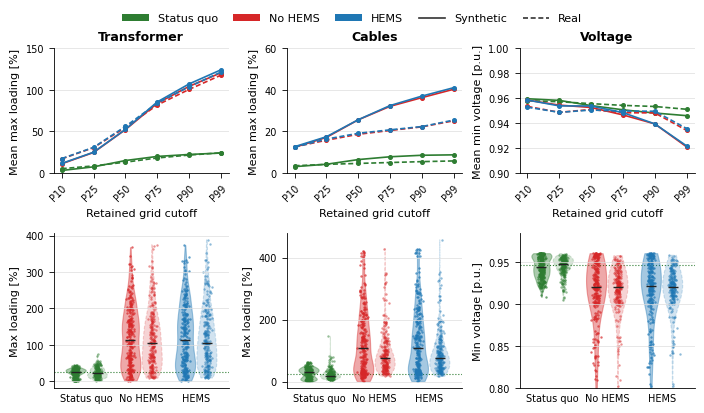

In [4]:
comparison = load_powerflow_cutoff_comparison(
    specs_by_source=context["specs_by_source"],
    stage_order=CASES,
    excluded_grids=context["excluded_grids"],
)
profile = comparison["profile"]
display(comparison["coverage_summary"].pivot(index="data_source", columns="comparison_stage", values="grids"))

OVERVIEW = dict(
    group_col="comparison_stage",
    source_col="network",
    color_map=CASE_COLORS,
    group_labels=CASE_DISPLAY,
    reference_group=PRE,
    asset_cutoff_percentile=0.99,
    asset_percentiles=(0.10, 0.25, 0.50, 0.75, 0.90, 1.0),
    filter_scope="grid",
    worst_asset_per_grid=True,
    curve_y_axis_limits=CURVE_Y_LIMITS,
    distribution_y_axis_limits={"Voltage": (0.80, None)},
)
fig = plot_powerflow_asset_cutoff_overview_static(
    profile, save_path=FIGURE_DIR / "pre_post_flex_no_flex_asset_cutoff_overview", **OVERVIEW
)
plt.show()

### Per provider (diagnostic; names the DSOs, not for publication)

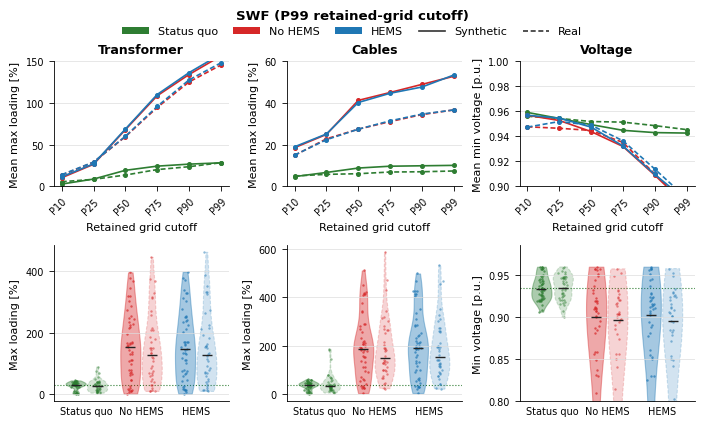

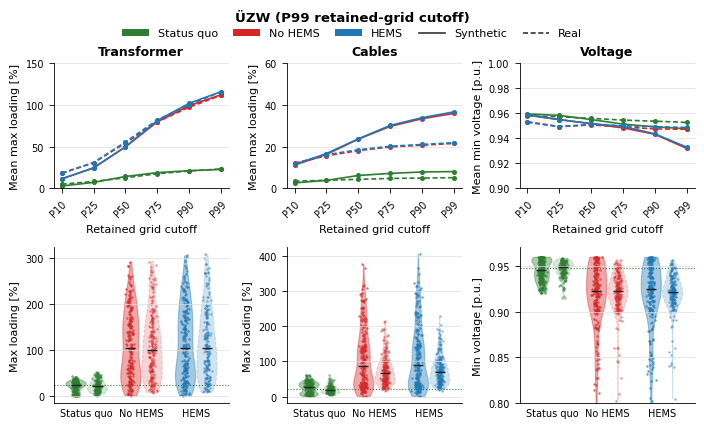

In [5]:
for provider in context["providers"]:
    label = PROVIDER_LABELS[provider]
    fig = plot_powerflow_asset_cutoff_overview_static(
        profile[profile["provider"] == label],
        title=label,
        save_path=FIGURE_DIR / f"pre_post_flex_no_flex_asset_cutoff_overview_{provider}",
        **OVERVIEW,
    )
    plt.show()

## Expansion costs

Staged LV rules (`de_lv_staged_2026`) per grid, summed over the common grid set of all cases.

In [6]:
grid_costs = expansion_grid_costs(context["expansion_tables_by_source"], CASES)
if grid_costs.empty:
    print("No expansion analyses of this run yet.")
else:
    costs = expansion_cost_comparison(grid_costs, stage_labels=CASES, excluded_grids=context["excluded_grids"])
    costs_by_provider = expansion_cost_comparison(
        grid_costs, stage_labels=CASES, excluded_grids=context["excluded_grids"], by="data_source"
    )
    display(costs["excluded"])
    display(costs["grids"].pivot(index="data_source", columns="stage", values=["grids", "total_cost_eur"]))
    plot_expansion_cost_comparison_bar(
        costs["costs"],
        stage_order=(INFLEX, HEMS),
        color_map=CASE_COLORS,
        output_path=FIGURE_DIR / "expansion_cost_bar",
        title="Expansion cost: synthetic vs real grids",
        show=False,
    )
    plt.show()
    display(expansion_cost_reduction_summary(costs["costs"], post_inflex_label=INFLEX, post_flex_label=HEMS))
    display(costs["reinforcements"])

No expansion analyses of this run yet.


### Per provider (diagnostic)

In [7]:
if not grid_costs.empty:
    display(expansion_cost_reduction_summary(costs_by_provider["costs"], post_inflex_label=INFLEX, post_flex_label=HEMS))
    display(costs_by_provider["grids"].pivot(index="data_source", columns="stage", values=["grids", "total_cost_eur"]))

## Cable capacity and transported current

Whether a loading difference comes from installed ampacity, from the transported peak current, or from both.

cables  grids  median_capacity_a  median_peak_current_a  median_max_loading_percent
data_source comparison_stage                                                                                     
Real        HEMS               24383    254              178.0                   34.2                        20.6
            INFLEX             24383    254              178.0                   33.9                        20.3
            status-quo         24735    255              178.0                    7.3                         4.4
Synthetic   HEMS               27641    282              142.0                   40.5                        24.3
            INFLEX             27641    282              142.0                   39.6                        24.1
            status-quo         27641    282              142.0                    9.6                         5.4

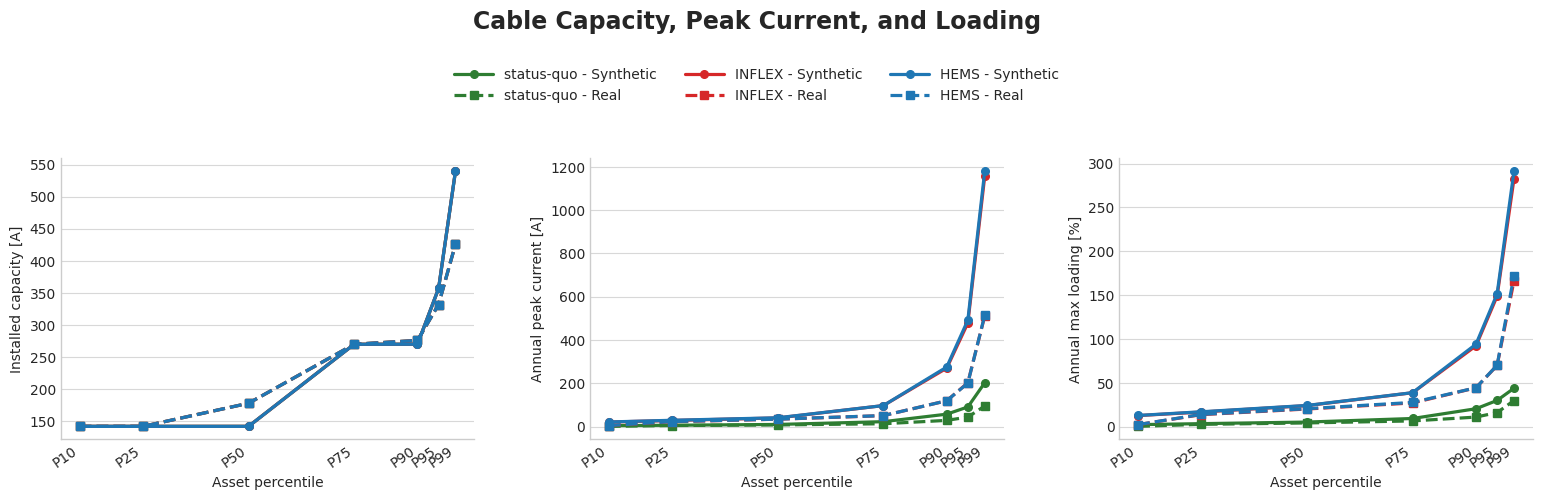

In [8]:
cables = load_cable_loading_decomposition(
    specs_by_source=context["specs_by_source"], excluded_grids=context["excluded_grids"]
)
pooled_cables = cables.assign(data_source=cables["network"])
display(
    pooled_cables.groupby(["data_source", "comparison_stage"], observed=True)
    .agg(
        cables=("asset_id", "count"),
        grids=("grid", "nunique"),
        median_capacity_a=("installed_capacity_a", "median"),
        median_peak_current_a=("max_current_a", "median"),
        median_max_loading_percent=("max_loading_percent", "median"),
    )
    .round(1)
)
plot_cable_capacity_current_loading_comparison(
    pooled_cables,
    stage_order=tuple(CASES),
    color_map=CASE_COLORS,
    save_path=FIGURE_DIR / "cable_capacity_current_loading",
)
plt.show()

## Voltage extremes

In [9]:
voltage = load_voltage_summaries_for_powerflow_comparison(
    specs_by_source=context["specs_by_source"], excluded_grids=context["excluded_grids"]
)
pooled_voltage = {}
for source, by_case in voltage.items():
    for case, frame in by_case.items():
        pooled_voltage.setdefault(group_network(source), {}).setdefault(case, []).append(frame)
pooled_voltage = {
    network: {case: pd.concat(frames, ignore_index=True) for case, frames in by_case.items()}
    for network, by_case in pooled_voltage.items()
}
plot_voltage_deviation_histogram_comparison(pooled_voltage, lower_limit=0.90, upper_limit=1.10, show=False)

## Transformer import (synthetic grids only)

The real-grid summaries store no signed transformer-import time series.

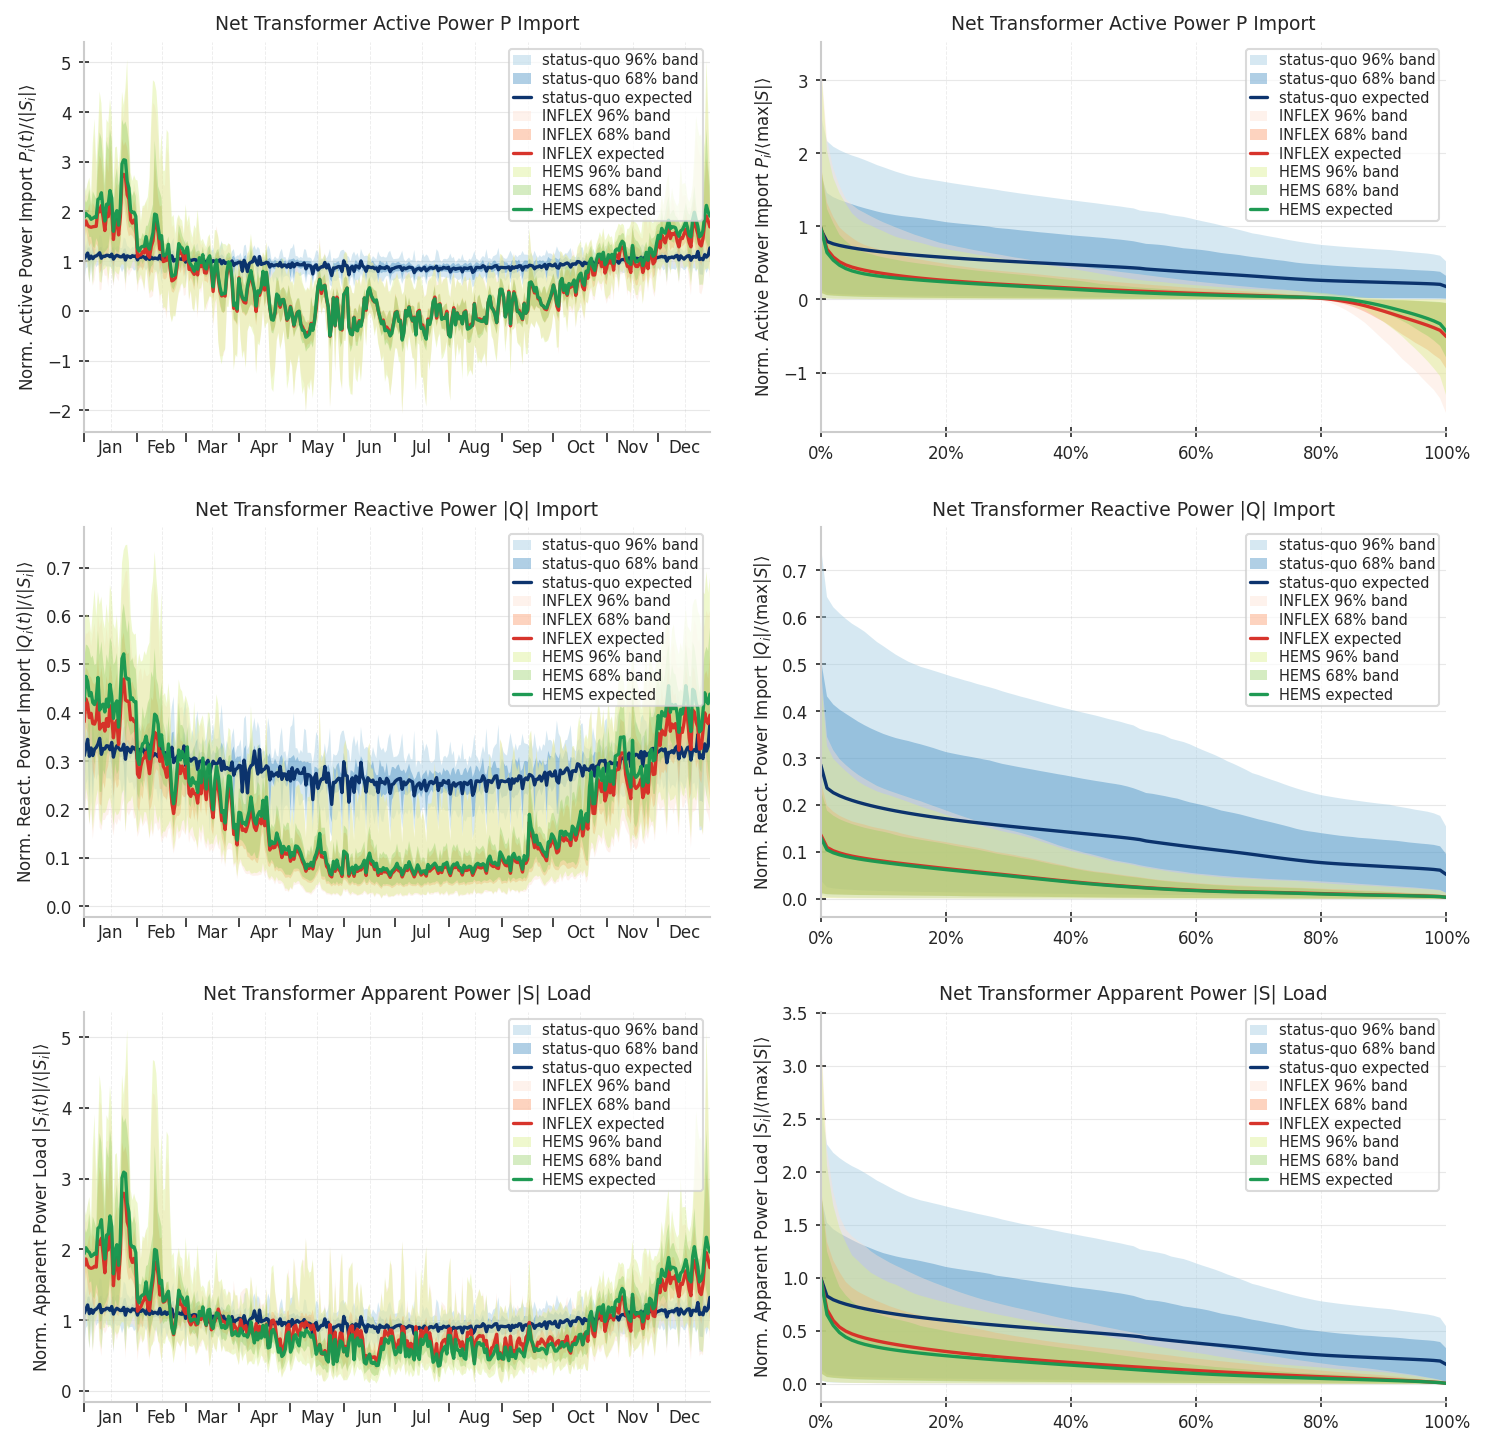

In [10]:
frames = []
for source, specs in context["specs_by_source"].items():
    if group_network(source) == "Synthetic":
        distribution = load_transformer_import_distributions_for_specs(specs)
        if not distribution.empty:
            frames.append(distribution.assign(data_source=source))
if not frames:
    print("No transformer-import time series: this run writes compact summaries only.")
else:
    fig = plot_transformer_import_distributions_matplotlib(
        pd.concat(frames, ignore_index=True), metrics=("p", "q", "s"), group_col="comparison_stage", show=False
    )
    fig.savefig(FIGURE_DIR / "transformer_import_distributions.svg", bbox_inches="tight")
    plt.show()